# Annotated fields: correct, wrong or missed

For one run and one sample, every field the person annotated is checked against what each
model wrote at the same place:

| Outcome | Meaning |
|---|---|
| **Correct** | the model's value matches the annotation |
| **Wrong** | the model wrote a different value there |
| **Missed** | the model wrote nothing there, or left it empty |

Fields the person left empty are not shown. The matrix has one panel per model; each row is
a kind of field, with the number annotated in brackets, and each cell is the share of that
row. The table underneath lists every annotated field.

**To look at another run or sample:** change `RUN` and `SAMPLE` in the next cell.


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    import os
    os.chdir(Path.cwd().parent)

RUN    = "v4-sample14"                           # a folder under data/output/rda/runs/
SAMPLE = 14
RESULT = Path("data/output/rda/runs") / RUN / "evaluation_results.xlsx"
CHART  = Path("data/output/rda/runs") / RUN / f"field_matrix_sample{SAMPLE}.png"
MODELS = ["llama3.1-8b", "gemma4-e4b", "llama3.3-70b"]
OUTCOMES = ["Correct", "Wrong", "Missed"]

INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "text.color": INK,
    "axes.titlecolor": INK, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
})
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 220)


## 1. One outcome per annotated field and model


In [2]:
details = pd.read_excel(RESULT, sheet_name="details")
if "sample" in details:
    details = details[details["sample"] == SAMPLE]
details["model"] = details["model"].str.replace(":", "-")


def outcome(rows):
    """The evaluation writes one or two rows per annotated field; reduce them to one outcome."""
    if (rows.verdict == "Correct").any():
        return "Correct"
    wrote = rows[(rows.verdict == "Hallucinated") & (rows.reason != "empty where the reference has a value")]
    return "Wrong" if len(wrote) else "Missed"


def kind(path):
    """A readable name for a kind of field: dmp.dataset[3].distribution[0].host.title -> dataset > host > title"""
    p = re.sub(r"\[\d+\]", "", path.replace("dmp.", "", 1))
    return p.replace("distribution.", "").replace(".", " > ").replace("_", " ")


annotated = details[details["reference value"].notna()]
fields = (annotated.groupby(["field", "model"]).apply(outcome, include_groups=False)
          .rename("outcome").reset_index())
fields["kind"] = fields["field"].map(kind)
values = annotated.drop_duplicates("field").set_index("field")["reference value"]
wrote = (annotated[annotated["model value"].notna()]
         .drop_duplicates(["field", "model"]).set_index(["field", "model"])["model value"])

models = [m for m in MODELS if m in set(fields.model)]
n_fields = fields.field.nunique()
print(f"run {RUN}, sample {SAMPLE}: {n_fields} annotated fields, models: {', '.join(models)}")
display(fields.pivot_table(index="model", columns="outcome", values="field", aggfunc="count", fill_value=0)
        .reindex(index=models, columns=OUTCOMES, fill_value=0))


run v4-sample14, sample 14: 135 annotated fields, models: llama3.1-8b, gemma4-e4b, llama3.3-70b


outcome,Correct,Wrong,Missed
model,,,
llama3.1-8b,56,3,76
gemma4-e4b,9,11,115
llama3.3-70b,73,9,53


## 2. The matrix

Rows: kinds of annotated fields, most frequent first, with how many were annotated.
Columns: what each model did with them. A row's three cells add up to 100%.


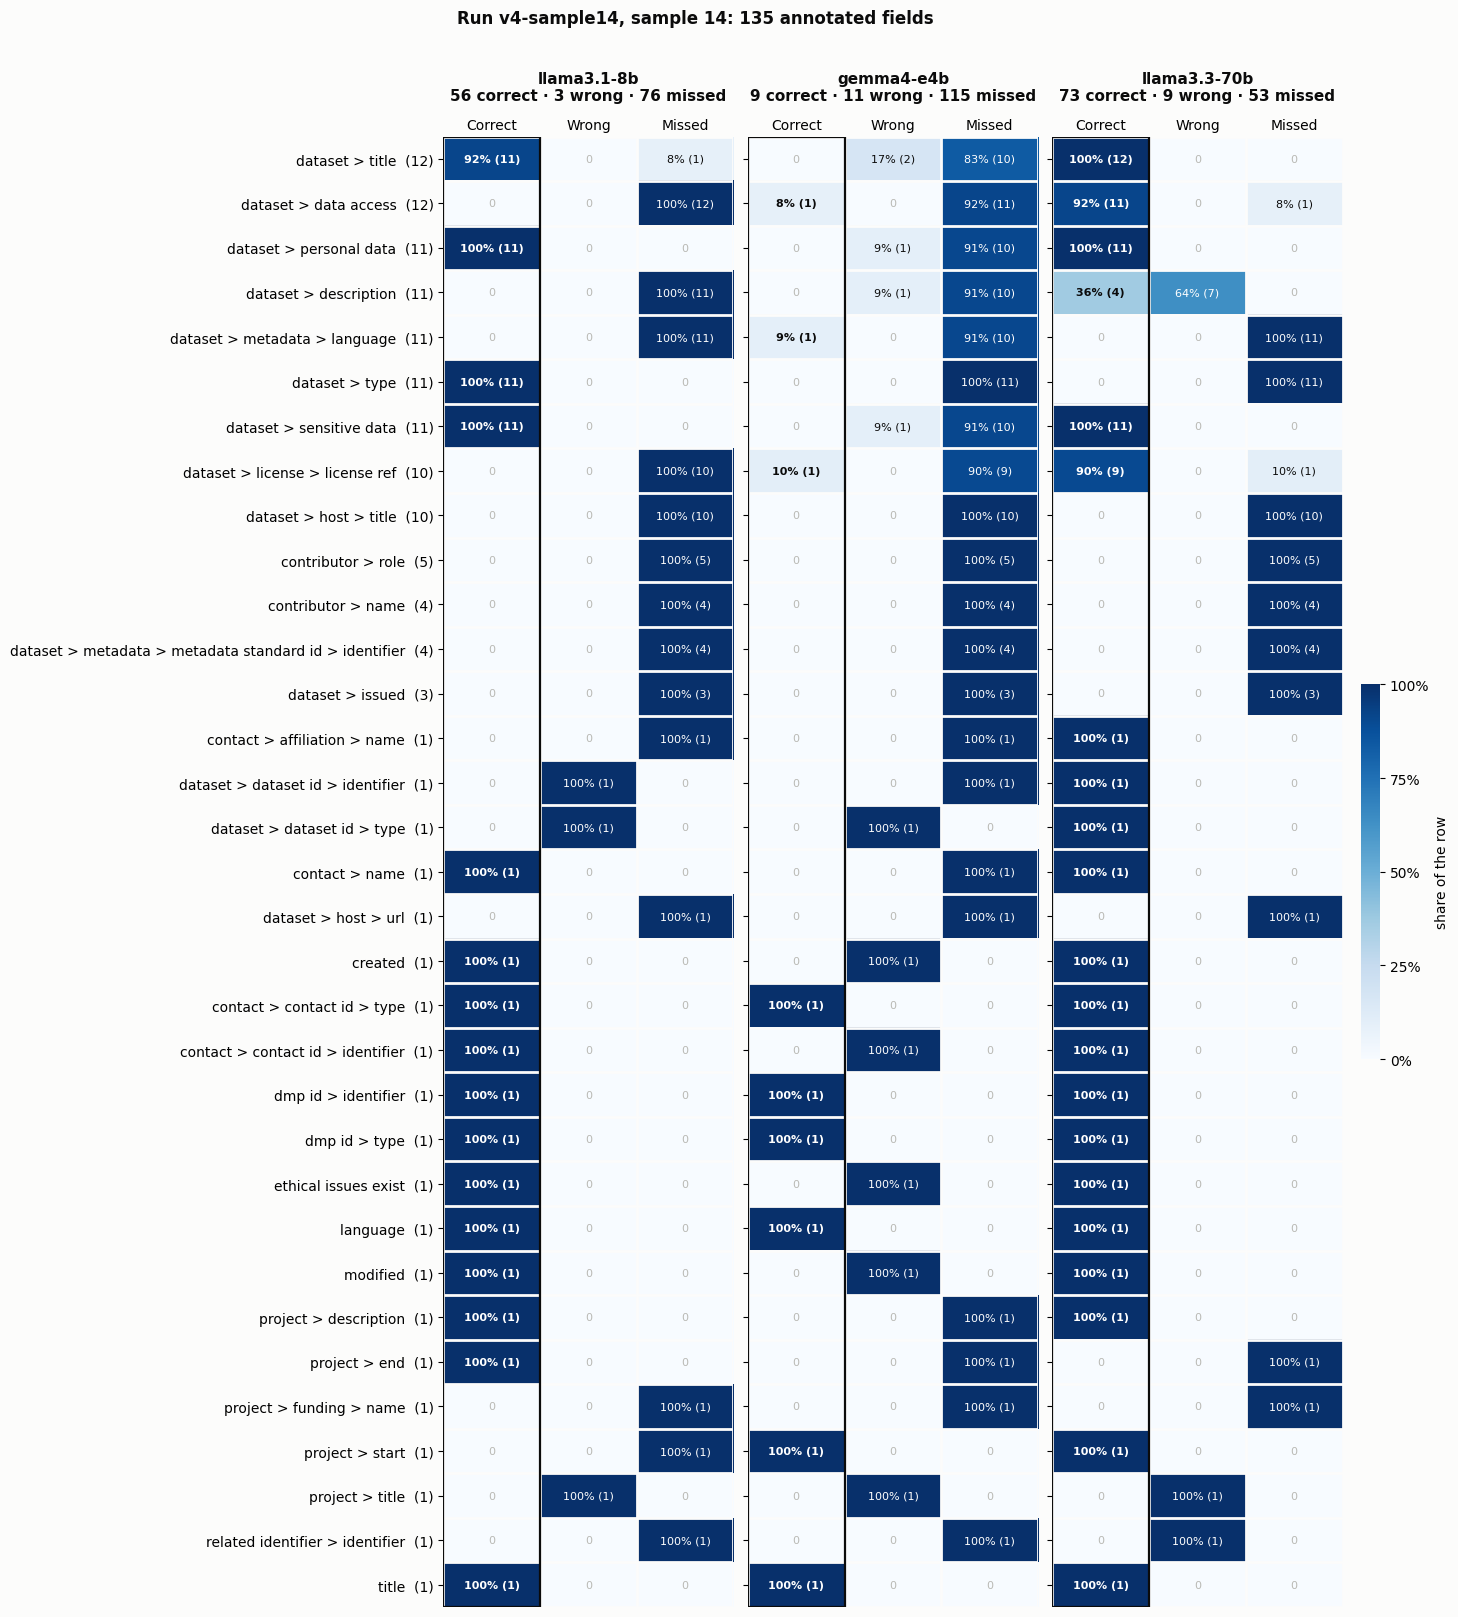

saved -> data\output\rda\runs\v4-sample14\field_matrix_sample14.png


In [3]:
order = fields.drop_duplicates("field")["kind"].value_counts()
kinds = list(order.index)

fig, axes = plt.subplots(1, len(models), figsize=(3.6 * len(models) + 3.2, 0.42 * len(kinds) + 1.8),
                         sharey=True, squeeze=False)
axes = axes[0]
for ax, m in zip(axes, models):
    counts = (fields[fields.model == m].groupby(["kind", "outcome"]).size().unstack(fill_value=0)
              .reindex(index=kinds, columns=OUTCOMES, fill_value=0))
    share = counts.div(counts.sum(axis=1).replace(0, 1), axis=0).to_numpy()
    im = ax.imshow(share, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    for i in range(len(kinds)):
        for j in range(len(OUTCOMES)):
            v, n = share[i, j], counts.iloc[i, j]
            ax.text(j, i, f"{v:.0%} ({n})" if n else "0", ha="center", va="center", fontsize=8,
                    fontweight="bold" if j == 0 and n else "normal",
                    color="#b9b9b4" if n == 0 else ("white" if v > 0.55 else INK))
    total = counts.sum()
    ax.set_title(f"{m}\n{total['Correct']} correct · {total['Wrong']} wrong · {total['Missed']} missed",
                 pad=26, fontsize=11)
    ax.set_xticks(range(len(OUTCOMES)))
    ax.set_xticklabels(OUTCOMES)
    ax.xaxis.tick_top()
    ax.set_xticks(np.arange(-.5, len(OUTCOMES), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(kinds), 1), minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=2)
    ax.tick_params(which="minor", length=0)
    ax.tick_params(axis="x", length=0)
    ax.add_patch(plt.Rectangle((-.5, -.5), 1, len(kinds), fill=False, edgecolor=INK, linewidth=1.6, zorder=5))
    for spine in ax.spines.values():
        spine.set_visible(False)
axes[0].set_yticks(range(len(kinds)))
axes[0].set_yticklabels([f"{k}  ({order[k]})" for k in kinds])
plt.tight_layout()
cbar = fig.colorbar(im, ax=list(axes), fraction=0.02, pad=0.02, label="share of the row")
cbar.outline.set_visible(False)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0%", "25%", "50%", "75%", "100%"])
fig.suptitle(f"Run {RUN}, sample {SAMPLE}: {n_fields} annotated fields", fontweight="bold", y=1.03)
fig.savefig(CHART, dpi=200, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"saved -> {CHART}")


## 3. Every annotated field

One row per field the person annotated: the annotated value, each model's outcome, and,
when it was wrong, what the model wrote instead.


In [4]:
wide = fields.pivot(index="field", columns="model", values="outcome").reindex(columns=models)
wide.insert(0, "annotated value", values.reindex(wide.index).astype(str).str.slice(0, 60))
for m in models:
    wide[f"{m} wrote"] = [str(wrote.get((f, m), ""))[:45] if wide.loc[f, m] == "Wrong" else ""
                          for f in wide.index]
natural = lambda f: [int(x) if x.isdigit() else x for x in re.split(r"(\d+)", f)]
display(wide.loc[sorted(wide.index, key=natural)].reset_index())


model,field,annotated value,llama3.1-8b,gemma4-e4b,llama3.3-70b,llama3.1-8b wrote,gemma4-e4b wrote,llama3.3-70b wrote
0,dmp.contact.affiliation[0].name,Hakai Institute,Missed,Missed,Correct,,,
1,dmp.contact.contact_id[0].identifier,0000-0001-9317-0364,Correct,Wrong,Correct,,0000-0003-0644-4174,
2,dmp.contact.contact_id[0].type,orcid,Correct,Correct,Correct,,,
3,dmp.contact.name,Brett Johnson,Correct,Missed,Correct,,,
4,dmp.contributor[0].name,Brett Johnson,Missed,Missed,Missed,,,
5,dmp.contributor[0].role[0],Principal Investigator,Missed,Missed,Missed,,,
6,dmp.contributor[0].role[1],Data Manager,Missed,Missed,Missed,,,
7,dmp.contributor[1].name,Brian Hunt,Missed,Missed,Missed,,,
8,dmp.contributor[1].role[0],Principal Investigator,Missed,Missed,Missed,,,
9,dmp.contributor[2].name,Tim van der Stap,Missed,Missed,Missed,,,
